In [157]:
import re
import string
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter

import nltk
from PIL import Image
from wordcloud import WordCloud,STOPWORDS,ImageColorGenerator
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


In [158]:
df_train=pd.read_csv("/kaggle/input/competitions/nlp-getting-started/train.csv")
df_test=pd.read_csv("/kaggle/input/competitions/nlp-getting-started/test.csv")

In [159]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [160]:
df_train.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [161]:
df_train=df_train.dropna(how="any",axis=1)
df_train

,id,text,target
0,1,Our Deeds are the Reason of this #earthquake M...,1
1,4,Forest fire near La Ronge Sask. Canada,1
2,5,All residents asked to 'shelter in place' are ...,1
3,6,"13,000 people receive #wildfires evacuation or...",1
4,7,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...
7608,10869,Two giant cranes holding a bridge collapse int...,1
7609,10870,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,Police investigating after an e-bike collided ...,1


In [162]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,accuracy_score,confusion_matrix, classification_report

In [163]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

<>:5: SyntaxWarning: invalid escape sequence '\['
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:5: SyntaxWarning: invalid escape sequence '\['
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_58/511036377.py:5: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
/tmp/ipykernel_58/511036377.py:6: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
/tmp/ipykernel_58/511036377.py:10: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


In [164]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [165]:
stop_words=stopwords.words('english')
more_stopwords=['u','im','c']
stop_words=stop_words+more_stopwords

In [166]:
def remove_stopwords(text):
    text=' '.join(word for word in text.split(' ') if word not in stop_words)
    return text

In [167]:
stemmer=nltk.SnowballStemmer("english")

def preprocess_data(text):
    # Text Cleaning
    text=clean_text(text)
    # Remove StopWords
    text=' '.join(word for word in text.split(' ') if word not in stop_words)
    # Stemming
    text=' '.join(stemmer.stem(word) for word in text.split(' '))

    return text

In [168]:
df_train['text_cleaned']=df_train['text'].apply(preprocess_data)

In [169]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

In [170]:
text_vectors_matrix=vectorizer.fit_transform(df_train['text_cleaned'])

In [171]:
y=df_train.iloc[:,[2]].values

In [172]:
X_train,X_test,y_train,y_test=train_test_split(text_vectors_matrix,y,test_size=0.2,random_state=69)

In [173]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 52591 stored elements and shape (6090, 13489)>

In [174]:
# model=MultinomialNB()
model=LogisticRegression()

In [175]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [176]:
# 4. Make predictions on the test data
predictions = model.predict(X_test)

# 5. Evaluate the model performance
print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.814182534471438

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.92      0.85       891
           1       0.86      0.66      0.75       632

    accuracy                           0.81      1523
   macro avg       0.83      0.79      0.80      1523
weighted avg       0.82      0.81      0.81      1523



In [177]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# Calculate and print the F1-Score
# For binary classification (0/1), "macro" or "binary" averaging works well
f1 = f1_score(y_test, predictions, average='binary')
print(f"Binary F1-Score: {f1:.4f}")

Binary F1-Score: 0.7475


In [178]:
# Generate the raw Confusion Matrix array
cm = confusion_matrix(y_test, predictions)
print("\nRaw Confusion Matrix Array:")
print(cm)


Raw Confusion Matrix Array:
[[821  70]
 [213 419]]


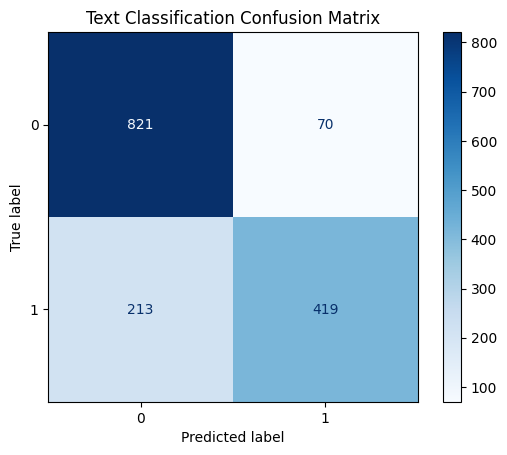

In [179]:
# Plot a clean, professional Confusion Matrix visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Text Classification Confusion Matrix")
plt.show()

In [180]:
X_submit_test = vectorizer.transform(df_test['text']) 

test_preds = model.predict_proba(X_submit_test)[:, 1]

In [181]:
# ── Submission ─────────────────────────────────────────────
submission = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/sample_submission.csv')

submission['target'] = (test_preds >= 0.5).astype(int)
submission.to_csv('submission.csv', index=False)
print('Submission saved successfully!')

Submission saved successfully!
